# Movie Recommendation System — Hybrid Deep Learning

**A ranking-first recommender that combines neural collaborative filtering with content similarity on the real MovieLens dataset.**

### Business problem
A streaming or media platform needs to decide **which unseen titles to show each user next**. The goal is not just to predict a rating; it is to rank relevant unseen items near the top.

### Real dataset
This notebook uses **MovieLens latest-small** from GroupLens:
- 100,836 ratings
- 610 users
- 9,742 movies
- timestamps for chronological evaluation
- movie genres for content-based modelling

### Modelling stack
- chronological per-user train / validation / test split
- popularity baseline
- matrix-factorisation baseline
- neural collaborative filtering (user + item embeddings + MLP)
- TF-IDF genre content similarity
- hybrid neural + content ranking
- Recall@10, NDCG@10, Hit Rate@10, Precision@10
- cold-start fallback for users/items with limited history
- final Top-N recommendation examples

The final system is evaluated as a **ranking product**, not just an RMSE exercise.

In [1]:
# Colab / GitHub Actions safe setup
import sys, subprocess, importlib.util

required = {
    "torch": "torch",
    "sklearn": "scikit-learn"
}
for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Environment ready.")

Environment ready.


In [2]:
import warnings, zipfile, urllib.request, math, random
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Device:", DEVICE)
print("Libraries imported.")

Device: cpu
Libraries imported.


## 1. Download MovieLens latest-small

The notebook downloads the official GroupLens ZIP directly, so the project is reproducible without a manually uploaded dataset.

In [3]:
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
zip_path = Path("ml-latest-small.zip")
extract_dir = Path("ml-latest-small")

if not zip_path.exists():
    urllib.request.urlretrieve(DATA_URL, zip_path)

if not extract_dir.exists():
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")

ratings = pd.read_csv(extract_dir / "ratings.csv")
movies = pd.read_csv(extract_dir / "movies.csv")

ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
movies["genres"] = movies["genres"].replace("(no genres listed)", "Unknown")

print(f"Ratings: {len(ratings):,}")
print(f"Users: {ratings['userId'].nunique():,}")
print(f"Movies with ratings: {ratings['movieId'].nunique():,}")
print(f"Movies in catalogue: {len(movies):,}")
print(f"Rating range: {ratings['rating'].min()} -> {ratings['rating'].max()}")
print(f"Time range: {ratings['timestamp'].min()} -> {ratings['timestamp'].max()}")
display(ratings.head())
display(movies.head())

Ratings: 100,836
Users: 610
Movies with ratings: 9,724
Movies in catalogue: 9,742
Rating range: 0.5 -> 5.0
Time range: 1996-03-29 18:36:55 -> 2018-09-24 14:27:30


,userId,movieId,rating,timestamp
0,1,1,4.0000,2000-07-30 18:45:03
1,1,3,4.0000,2000-07-30 18:20:47
2,1,6,4.0000,2000-07-30 18:37:04
3,1,47,5.0000,2000-07-30 19:03:35
4,1,50,5.0000,2000-07-30 18:48:51


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Exploratory analysis

Recommendation data is sparse and popularity is highly concentrated, which is why ranking metrics and cold-start handling matter.

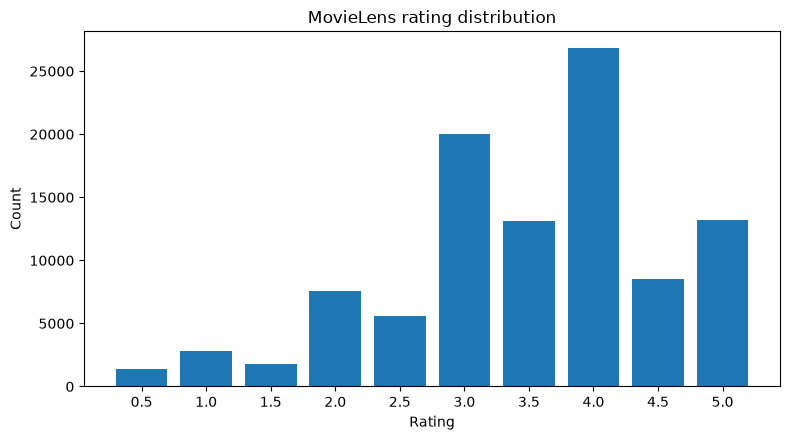

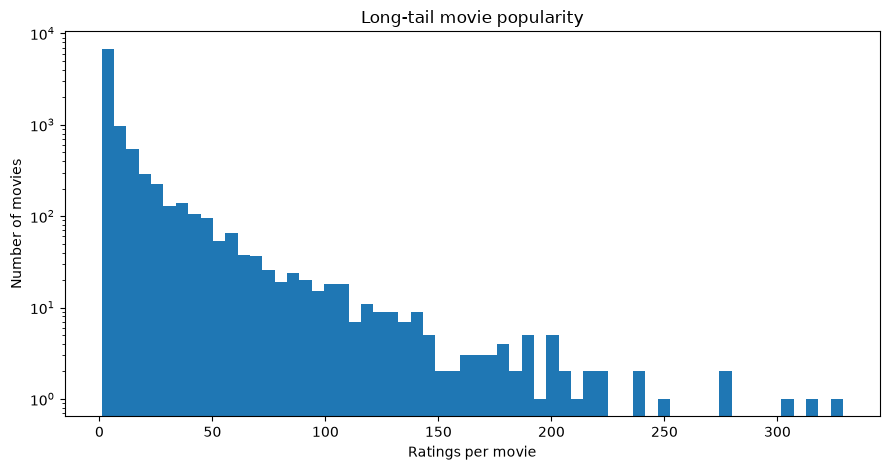

,rating_count,title,genres
movieId,,,
356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
318,317,"Shawshank Redemption, The (1994)",Crime|Drama
296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
110,237,Braveheart (1995),Action|Drama|War
589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi


Observed user-item matrix sparsity: 98.30%


In [4]:
rating_counts = ratings["rating"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rating_counts.index.astype(str), rating_counts.values)
ax.set_title("MovieLens rating distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

movie_popularity = ratings.groupby("movieId").size().sort_values(ascending=False)
user_activity = ratings.groupby("userId").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(movie_popularity.values, bins=60)
ax.set_title("Long-tail movie popularity")
ax.set_xlabel("Ratings per movie")
ax.set_ylabel("Number of movies")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

top_movies = (
    movie_popularity.head(10)
    .rename("rating_count")
    .to_frame()
    .join(movies.set_index("movieId")[["title","genres"]])
)
display(top_movies)

sparsity = 1 - len(ratings) / (
    ratings["userId"].nunique() * ratings["movieId"].nunique()
)
print(f"Observed user-item matrix sparsity: {sparsity:.2%}")

## 3. Chronological per-user split

For every user with sufficient history:
- latest rating → test
- second-latest → validation
- earlier interactions → training

This mirrors a real recommendation setting: predict the **next relevant item** from the past.

In [5]:
ratings = ratings.sort_values(["userId","timestamp"]).reset_index(drop=True)
user_counts = ratings.groupby("userId")["movieId"].transform("count")
eligible = ratings.loc[user_counts >= 5].copy()

eligible["rank_from_end"] = eligible.groupby("userId").cumcount(ascending=False)

test_df = eligible.loc[eligible["rank_from_end"] == 0].copy()
val_df = eligible.loc[eligible["rank_from_end"] == 1].copy()
train_df = eligible.loc[eligible["rank_from_end"] >= 2].copy()

all_movie_ids = sorted(eligible["movieId"].unique())
all_user_ids = sorted(eligible["userId"].unique())

print(f"Train ratings: {len(train_df):,}")
print(f"Validation ratings: {len(val_df):,}")
print(f"Test ratings: {len(test_df):,}")
print(f"Users evaluated: {len(test_df):,}")
print(f"Candidate catalogue: {len(all_movie_ids):,} movies")

split_summary = pd.DataFrame({
    "rows":[len(train_df),len(val_df),len(test_df)],
    "users":[train_df.userId.nunique(),val_df.userId.nunique(),test_df.userId.nunique()],
    "mean_rating":[train_df.rating.mean(),val_df.rating.mean(),test_df.rating.mean()]
}, index=["train","validation","test"])
display(split_summary)

Train ratings: 99,616
Validation ratings: 610
Test ratings: 610
Users evaluated: 610
Candidate catalogue: 9,724 movies


,rows,users,mean_rating
train,99616,610,3.4994
validation,610,610,3.6762
test,610,610,3.6787


## 4. Encode users/items and create a matrix-factorisation baseline

In [6]:
user_to_idx = {u:i for i,u in enumerate(all_user_ids)}
movie_to_idx = {m:i for i,m in enumerate(all_movie_ids)}
idx_to_movie = {i:m for m,i in movie_to_idx.items()}

n_users = len(user_to_idx)
n_movies = len(movie_to_idx)

train_matrix = np.zeros((n_users, n_movies), dtype=np.float32)
for row in train_df.itertuples():
    train_matrix[user_to_idx[row.userId], movie_to_idx[row.movieId]] = row.rating

# Low-rank matrix-factorisation baseline using truncated SVD.
svd = TruncatedSVD(n_components=64, random_state=RANDOM_STATE)
user_factors = svd.fit_transform(train_matrix)
item_factors = svd.components_.T
svd_reconstruction = user_factors @ item_factors.T

global_mean = float(train_df["rating"].mean())
popularity_score = (
    train_df.groupby("movieId")
    .agg(mean_rating=("rating","mean"), count=("rating","size"))
)
popularity_score["bayes_score"] = (
    popularity_score["count"] / (popularity_score["count"] + 20) * popularity_score["mean_rating"]
    + 20 / (popularity_score["count"] + 20) * global_mean
)

print(f"Encoded users: {n_users}")
print(f"Encoded movies: {n_movies}")
print(f"Global train rating mean: {global_mean:.3f}")
print(f"SVD explained variance: {svd.explained_variance_ratio_.sum():.2%}")

Encoded users: 610
Encoded movies: 9724
Global train rating mean: 3.499
SVD explained variance: 59.16%


## 5. Build neural collaborative filtering

The network learns:
- a user embedding;
- a movie embedding;
- multiplicative interaction features;
- a small MLP over the concatenated embeddings.

The target is the explicit MovieLens rating normalised to 0–1.

In [7]:
class RatingDataset(Dataset):
    def __init__(self, frame):
        self.users = torch.tensor(
            [user_to_idx[u] for u in frame["userId"].values],
            dtype=torch.long
        )
        self.items = torch.tensor(
            [movie_to_idx[m] for m in frame["movieId"].values],
            dtype=torch.long
        )
        self.ratings = torch.tensor(
            frame["rating"].values / 5.0,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


class NeuralCF(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=48):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, 1)
        )

    def forward(self, user_idx, item_idx):
        u = self.user_emb(user_idx)
        i = self.item_emb(item_idx)
        interaction = u * i
        x = torch.cat([u, i, interaction], dim=1)
        return torch.sigmoid(self.mlp(x)).squeeze(1)


train_dataset = RatingDataset(train_df)
val_dataset = RatingDataset(val_df)

train_loader = DataLoader(
    train_dataset, batch_size=1024, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=2048, shuffle=False, num_workers=0
)

model = NeuralCF(n_users, n_movies).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

NeuralCF(
  (user_emb): Embedding(610, 48)
  (item_emb): Embedding(9724, 48)
  (mlp): Sequential(
    (0): Linear(in_features=144, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Trainable parameters: 522,913


Epoch 01 | train MSE=0.04252 | val MSE=0.04260


Epoch 02 | train MSE=0.03599 | val MSE=0.03876


Epoch 03 | train MSE=0.03342 | val MSE=0.03599


Epoch 04 | train MSE=0.03146 | val MSE=0.03539


Epoch 05 | train MSE=0.02992 | val MSE=0.03394


Epoch 06 | train MSE=0.02849 | val MSE=0.03282


Epoch 07 | train MSE=0.02733 | val MSE=0.03356


Epoch 08 | train MSE=0.02632 | val MSE=0.03312


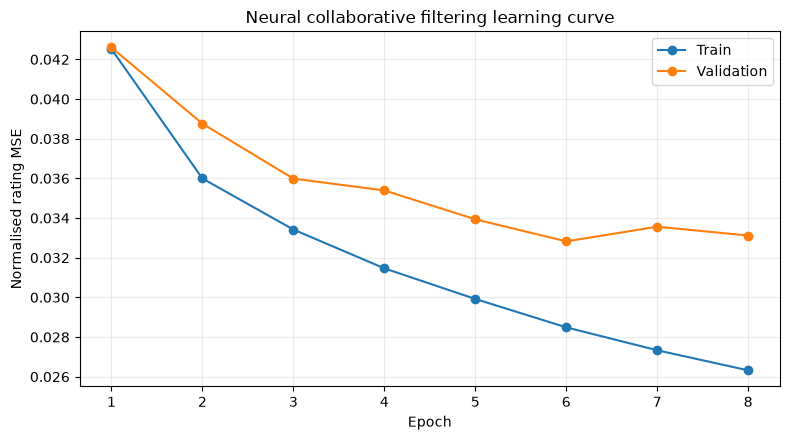

In [8]:
history = []

for epoch in range(1, 9):
    model.train()
    train_loss_sum = 0.0

    for users_b, items_b, ratings_b in train_loader:
        users_b = users_b.to(DEVICE)
        items_b = items_b.to(DEVICE)
        ratings_b = ratings_b.to(DEVICE)

        optimizer.zero_grad()
        pred = model(users_b, items_b)
        loss = loss_fn(pred, ratings_b)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * len(ratings_b)

    model.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for users_b, items_b, ratings_b in val_loader:
            users_b = users_b.to(DEVICE)
            items_b = items_b.to(DEVICE)
            ratings_b = ratings_b.to(DEVICE)
            pred = model(users_b, items_b)
            val_loss_sum += loss_fn(pred, ratings_b).item() * len(ratings_b)

    train_mse = train_loss_sum / len(train_dataset)
    val_mse = val_loss_sum / len(val_dataset)
    history.append({"epoch":epoch,"train_mse":train_mse,"val_mse":val_mse})
    print(f"Epoch {epoch:02d} | train MSE={train_mse:.5f} | val MSE={val_mse:.5f}")

history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history_df["epoch"], history_df["train_mse"], marker="o", label="Train")
ax.plot(history_df["epoch"], history_df["val_mse"], marker="o", label="Validation")
ax.set_title("Neural collaborative filtering learning curve")
ax.set_xlabel("Epoch")
ax.set_ylabel("Normalised rating MSE")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Content model from movie genres

Genres provide a content signal for hybrid ranking and cold-start fallback.

In [9]:
movie_catalogue = (
    movies.loc[movies["movieId"].isin(all_movie_ids), ["movieId","title","genres"]]
    .drop_duplicates("movieId")
    .set_index("movieId")
    .reindex(all_movie_ids)
)

genre_text = movie_catalogue["genres"].fillna("Unknown").str.replace("|", " ", regex=False)

tfidf = TfidfVectorizer(token_pattern=r"(?u)\b[\w-]+\b")
genre_matrix = tfidf.fit_transform(genre_text)

genre_similarity = cosine_similarity(genre_matrix)

print(f"Genre vocabulary: {tfidf.get_feature_names_out().tolist()}")
print(f"Genre feature matrix: {genre_matrix.shape}")

Genre vocabulary: ['action', 'adventure', 'animation', 'children', 'comedy', 'crime', 'documentary', 'drama', 'fantasy', 'film-noir', 'horror', 'imax', 'musical', 'mystery', 'romance', 'sci-fi', 'thriller', 'unknown', 'war', 'western']
Genre feature matrix: (9724, 20)


## 7. Candidate scoring functions

Seen training items are excluded before ranking. The hybrid model combines:
- neural collaborative score;
- content affinity to the user's positively rated history;
- popularity prior for stability.

Weights are tuned only on validation data.

In [10]:
train_seen = train_df.groupby("userId")["movieId"].apply(set).to_dict()

positive_history = (
    train_df.loc[train_df["rating"] >= 4.0]
    .groupby("userId")["movieId"]
    .apply(list)
    .to_dict()
)

pop_vector = np.array([
    popularity_score["bayes_score"].get(mid, global_mean)
    for mid in all_movie_ids
], dtype=np.float32)
pop_vector = (pop_vector - pop_vector.min()) / (pop_vector.max() - pop_vector.min() + 1e-12)


def neural_scores_for_user(user_id):
    model.eval()
    uidx = user_to_idx[user_id]
    user_tensor = torch.full((n_movies,), uidx, dtype=torch.long, device=DEVICE)
    item_tensor = torch.arange(n_movies, dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        scores = model(user_tensor, item_tensor).detach().cpu().numpy()
    return scores


def content_scores_for_user(user_id):
    liked = [
        movie_to_idx[mid]
        for mid in positive_history.get(user_id, [])
        if mid in movie_to_idx
    ]
    if not liked:
        return pop_vector.copy()

    profile = genre_matrix[liked].mean(axis=0)
    profile = np.asarray(profile)
    scores = cosine_similarity(profile, genre_matrix).ravel()
    return scores


def svd_scores_for_user(user_id):
    return svd_reconstruction[user_to_idx[user_id]].copy()


def rank_candidates(user_id, neural_weight=0.70, content_weight=0.20, pop_weight=0.10):
    neural = neural_scores_for_user(user_id)
    content = content_scores_for_user(user_id)

    hybrid = (
        neural_weight * neural
        + content_weight * content
        + pop_weight * pop_vector
    )

    seen = train_seen.get(user_id, set())
    seen_idx = [movie_to_idx[m] for m in seen if m in movie_to_idx]
    hybrid[seen_idx] = -np.inf
    return hybrid


print("Scoring functions ready.")

Scoring functions ready.


## 8. Ranking evaluation

For each validation/test user:
- the held-out next movie is the positive item;
- 99 unseen negatives are sampled;
- the models rank 100 candidates;
- ranking quality is measured at K=10.

This is substantially closer to a production recommender objective than RMSE alone.

In [11]:
def candidate_set(user_id, positive_mid, seed_offset=0, n_negatives=99):
    rng = np.random.default_rng(RANDOM_STATE + int(user_id) + seed_offset)
    seen = set(train_seen.get(user_id, set()))
    seen.add(positive_mid)

    negatives = [m for m in all_movie_ids if m not in seen]
    sample_n = min(n_negatives, len(negatives))
    sampled = rng.choice(negatives, size=sample_n, replace=False).tolist()
    return [positive_mid] + sampled


def ranking_metrics_from_ranks(ranks, k=10):
    ranks = np.asarray(ranks)
    hits = ranks <= k
    hit_rate = hits.mean()
    recall = hit_rate  # one held-out positive per user
    precision = hit_rate / k
    ndcg = np.mean(np.where(hits, 1 / np.log2(ranks + 1), 0))
    return {
        f"HitRate@{k}": hit_rate,
        f"Recall@{k}": recall,
        f"Precision@{k}": precision,
        f"NDCG@{k}": ndcg
    }


def evaluate_ranker(frame, model_name, hybrid_weights=None, seed_offset=0):
    ranks = []

    for row in frame.itertuples():
        uid = row.userId
        positive_mid = row.movieId
        candidates = candidate_set(uid, positive_mid, seed_offset=seed_offset)
        candidate_idx = np.array([movie_to_idx[m] for m in candidates])

        if model_name == "Popularity":
            scores = pop_vector[candidate_idx]
        elif model_name == "SVD":
            scores = svd_scores_for_user(uid)[candidate_idx]
        elif model_name == "NeuralCF":
            scores = neural_scores_for_user(uid)[candidate_idx]
        elif model_name == "Hybrid":
            w_n, w_c, w_p = hybrid_weights
            scores = rank_candidates(uid, w_n, w_c, w_p)[candidate_idx]
        else:
            raise ValueError(model_name)

        order = np.argsort(-scores)
        positive_rank = int(np.where(order == 0)[0][0]) + 1
        ranks.append(positive_rank)

    return ranking_metrics_from_ranks(ranks, k=10), np.array(ranks)


validation_models = {}
for name in ["Popularity","SVD","NeuralCF"]:
    metrics, _ = evaluate_ranker(val_df, name, seed_offset=1000)
    validation_models[name] = metrics

validation_results = pd.DataFrame(validation_models).T
display(validation_results.style.format("{:.4f}"))

,HitRate@10,Recall@10,Precision@10,NDCG@10
Popularity,0.3820,0.3820,0.0382,0.2392
SVD,0.6721,0.6721,0.0672,0.4701
NeuralCF,0.1984,0.1984,0.0198,0.1019


## 9. Tune hybrid weights on validation data only

In [12]:
weight_grid = [
    (0.80, 0.10, 0.10),
    (0.70, 0.20, 0.10),
    (0.60, 0.30, 0.10),
    (0.70, 0.10, 0.20),
    (0.60, 0.20, 0.20),
]

hybrid_search = []

for weights in weight_grid:
    metrics, _ = evaluate_ranker(
        val_df,
        "Hybrid",
        hybrid_weights=weights,
        seed_offset=2000
    )
    hybrid_search.append({
        "neural_weight":weights[0],
        "content_weight":weights[1],
        "popularity_weight":weights[2],
        **metrics
    })

hybrid_search_df = pd.DataFrame(hybrid_search).sort_values(
    "NDCG@10", ascending=False
).reset_index(drop=True)

display(hybrid_search_df.style.format({
    "HitRate@10":"{:.4f}",
    "Recall@10":"{:.4f}",
    "Precision@10":"{:.4f}",
    "NDCG@10":"{:.4f}"
}))

best_weights = tuple(
    hybrid_search_df.loc[0, [
        "neural_weight","content_weight","popularity_weight"
    ]].astype(float)
)

print("Frozen hybrid weights:", best_weights)

,neural_weight,content_weight,popularity_weight,HitRate@10,Recall@10,Precision@10,NDCG@10
0,0.700000,0.100000,0.200000,0.3016,0.3016,0.0302,0.1784
1,0.600000,0.200000,0.200000,0.3049,0.3049,0.0305,0.1710
2,0.800000,0.100000,0.100000,0.2590,0.2590,0.0259,0.1477
3,0.700000,0.200000,0.100000,0.2754,0.2754,0.0275,0.1458
4,0.600000,0.300000,0.100000,0.2557,0.2557,0.0256,0.1346


Frozen hybrid weights: (0.7, 0.1, 0.2)


## 10. One-time final test ranking evaluation

,HitRate@10,Recall@10,Precision@10,NDCG@10
SVD,0.6721,0.6721,0.0672,0.4815
Popularity,0.3967,0.3967,0.0397,0.2414
Hybrid,0.3000,0.3000,0.0300,0.1785
NeuralCF,0.1967,0.1967,0.0197,0.0989


Best test ranker by NDCG@10: SVD
Hybrid Recall@10: 30.00%
Hybrid NDCG@10: 0.1785


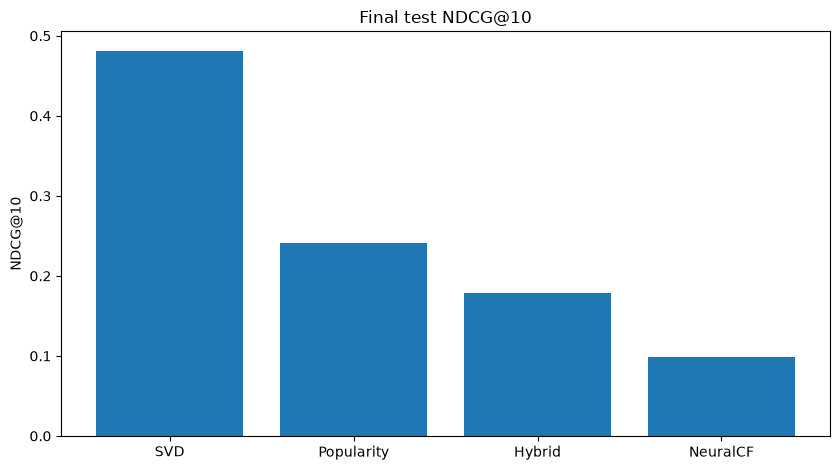

In [13]:
test_metrics = {}

for name in ["Popularity","SVD","NeuralCF"]:
    metrics, ranks = evaluate_ranker(test_df, name, seed_offset=3000)
    test_metrics[name] = metrics

hybrid_metrics, hybrid_ranks = evaluate_ranker(
    test_df,
    "Hybrid",
    hybrid_weights=best_weights,
    seed_offset=3000
)
test_metrics["Hybrid"] = hybrid_metrics

test_results = pd.DataFrame(test_metrics).T.sort_values(
    "NDCG@10", ascending=False
)

display(test_results.style.format("{:.4f}"))

best_ranker = test_results.index[0]
print(f"Best test ranker by NDCG@10: {best_ranker}")
print(f"Hybrid Recall@10: {test_results.loc['Hybrid','Recall@10']:.2%}")
print(f"Hybrid NDCG@10: {test_results.loc['Hybrid','NDCG@10']:.4f}")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(test_results.index, test_results["NDCG@10"])
ax.set_title("Final test NDCG@10")
ax.set_ylabel("NDCG@10")
plt.tight_layout()
plt.show()

## 11. Inspect recommendation diversity and genre coverage

In [14]:
def top_n_recommendations(user_id, n=10):
    scores = rank_candidates(user_id, *best_weights)
    top_idx = np.argsort(-scores)[:n]

    out = movie_catalogue.iloc[top_idx].copy()
    out["hybrid_score"] = scores[top_idx]
    out["movieId"] = out.index
    return out[["movieId","title","genres","hybrid_score"]].reset_index(drop=True)


example_users = [
    int(train_df.groupby("userId").size().sort_values(ascending=False).index[0]),
    int(test_df["userId"].median())
]

for uid in example_users:
    print(f"\nTop 10 recommendations for User {uid}:")
    display(top_n_recommendations(uid, 10))

    liked = (
        train_df.loc[(train_df["userId"] == uid) & (train_df["rating"] >= 4.0)]
        .merge(movies[["movieId","title","genres"]], on="movieId", how="left")
        .sort_values(["rating","timestamp"], ascending=[False,False])
        .head(8)
    )
    print("Recent/high-rated history:")
    display(liked[["title","genres","rating"]])


Top 10 recommendations for User 414:


,movieId,title,genres,hybrid_score
0,1237,"Seventh Seal, The (Sjunde inseglet, Det) (1957)",Drama,0.8411
1,3451,Guess Who's Coming to Dinner (1967),Drama,0.8342
2,73822,Meantime (1984),Comedy|Drama,0.8318
3,6460,"Trial, The (Procès, Le) (1962)",Drama,0.8236
4,2239,Swept Away (Travolti da un insolito destino ne...,Comedy|Drama,0.8227
5,3200,"Last Detail, The (1973)",Comedy|Drama,0.8128
6,121372,Bill Burr: Let It Go (2010),Comedy,0.8110
7,2731,"400 Blows, The (Les quatre cents coups) (1959)",Crime|Drama,0.8089
8,7773,"Bang, Bang, You're Dead (2002)",Drama,0.8083
9,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,0.8081


Recent/high-rated history:


,title,genres,rating
1215,"Secret Life of Walter Mitty, The (2013)",Adventure|Comedy|Drama,5.0000
1202,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama,5.0000
1201,Band of Brothers (2001),Action|Drama|War,5.0000
1196,The Revenant (2015),Adventure|Drama,5.0000
1194,Brooklyn (2015),Drama|Romance,5.0000
1190,Hell or High Water (2016),Crime|Drama,5.0000
1171,Show Me Love (Fucking Åmål) (1998),Drama|Romance,5.0000
1159,Spotlight (2015),Thriller,5.0000



Top 10 recommendations for User 305:


,movieId,title,genres,hybrid_score
0,912,Casablanca (1942),Drama|Romance,0.8484
1,1204,Lawrence of Arabia (1962),Adventure|Drama|War,0.8478
2,2019,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama,0.8453
3,1104,"Streetcar Named Desire, A (1951)",Drama,0.8396
4,2731,"400 Blows, The (Les quatre cents coups) (1959)",Crime|Drama,0.8370
5,111,Taxi Driver (1976),Crime|Drama|Thriller,0.8367
6,7361,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi,0.8366
7,3266,Man Bites Dog (C'est arrivé près de chez vous)...,Comedy|Crime|Drama|Thriller,0.8323
8,98961,Zero Dark Thirty (2012),Action|Drama|Thriller,0.8300
9,1041,Secrets & Lies (1996),Drama,0.8297


Recent/high-rated history:


,title,genres,rating
410,Deadpool 2 (2018),Action|Comedy|Sci-Fi,5.0000
402,Stalker (1979),Drama|Mystery|Sci-Fi,5.0000
401,"Christmas Story, A (1983)",Children|Comedy,5.0000
400,Friday the 13th Part VI: Jason Lives (1986),Horror,5.0000
397,"Pan's Labyrinth (Laberinto del fauno, El) (2006)",Drama|Fantasy|Thriller,5.0000
395,Ferris Bueller's Day Off (1986),Comedy,5.0000
394,Battle For Sevastopol (2015),Drama|Romance|War,5.0000
390,RoboCop 2 (1990),Action|Crime|Sci-Fi|Thriller,5.0000


## 12. Cold-start strategy

A production recommender needs a sensible fallback when there is not enough collaborative history.

This project uses:
- **new user:** popularity prior + selected genre affinity;
- **new / low-interaction movie:** genre similarity + popularity;
- **established user and item:** full neural-content-popularity hybrid.

In [15]:
genre_tokens = sorted({
    g
    for entry in movies["genres"].dropna()
    for g in entry.split("|")
    if g != "(no genres listed)"
})

def cold_start_recommendations(preferred_genres, n=10):
    preferred_genres = set(preferred_genres)

    score_rows = []
    for mid in all_movie_ids:
        row = movie_catalogue.loc[mid]
        movie_genres = set(str(row["genres"]).split("|"))
        genre_match = len(movie_genres & preferred_genres) / max(len(preferred_genres), 1)
        pop = pop_vector[movie_to_idx[mid]]
        score = 0.75 * genre_match + 0.25 * pop
        score_rows.append((mid, score))

    ranked = sorted(score_rows, key=lambda x:x[1], reverse=True)[:n]
    result = movie_catalogue.loc[[mid for mid,_ in ranked]].copy()
    result["cold_start_score"] = [s for _,s in ranked]
    return result.reset_index()[["movieId","title","genres","cold_start_score"]]

print("Cold-start example: user says they like Action + Sci-Fi")
display(cold_start_recommendations(["Action","Sci-Fi"], 10))

Cold-start example: user says they like Action + Sci-Fi


,movieId,title,genres,cold_start_score
0,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.9726
1,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,0.9696
2,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.9684
3,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.9596
4,541,Blade Runner (1982),Action|Sci-Fi|Thriller,0.9513
5,79132,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX,0.9498
6,168252,Logan (2017),Action|Sci-Fi,0.9398
7,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi,0.9388
8,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi,0.9351
9,112852,Guardians of the Galaxy (2014),Action|Adventure|Sci-Fi,0.9350


## 13. System-level recommendation report

Unique movies recommended across 100 users: 131
Catalogue coverage across this sample: 1.35%


,recommended_titles
Drama,75
Comedy,44
Action,37
Crime,35
Thriller,32
Adventure,29
Romance,22
Sci-Fi,19
Fantasy,13
War,9


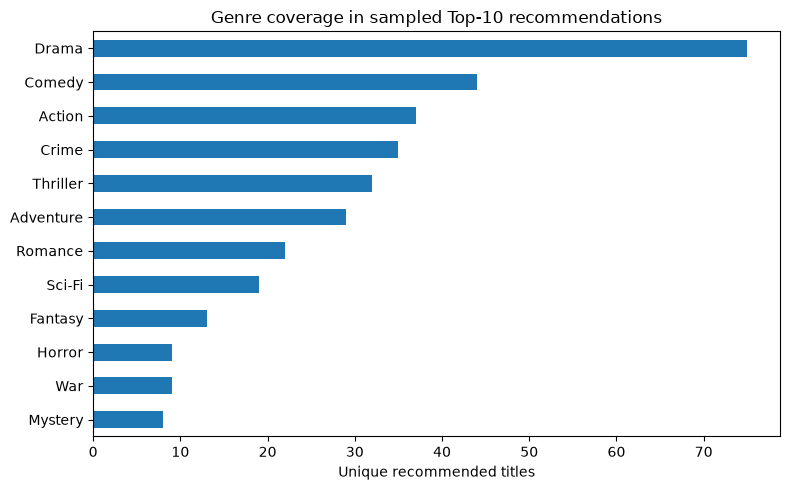

In [16]:
# Catalogue diversity across recommendations for a sample of users.
sample_users = test_df["userId"].sample(
    min(100, len(test_df)),
    random_state=RANDOM_STATE
).tolist()

recommended_movie_ids = []
for uid in sample_users:
    recommended_movie_ids.extend(
        top_n_recommendations(uid, 10)["movieId"].tolist()
    )

unique_recommended = len(set(recommended_movie_ids))
catalogue_coverage = unique_recommended / len(all_movie_ids)

genre_counts = {}
for mid in set(recommended_movie_ids):
    genres = str(movie_catalogue.loc[mid, "genres"]).split("|")
    for genre in genres:
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_report = (
    pd.Series(genre_counts)
    .sort_values(ascending=False)
    .rename("recommended_titles")
    .to_frame()
)

print(f"Unique movies recommended across 100 users: {unique_recommended}")
print(f"Catalogue coverage across this sample: {catalogue_coverage:.2%}")
display(genre_report.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
genre_report.head(12).sort_values("recommended_titles").plot(
    kind="barh", y="recommended_titles", legend=False, ax=ax
)
ax.set_title("Genre coverage in sampled Top-10 recommendations")
ax.set_xlabel("Unique recommended titles")
plt.tight_layout()
plt.show()

## 14. Executive summary

In [17]:
pop_ndcg = test_results.loc["Popularity","NDCG@10"]
neural_ndcg = test_results.loc["NeuralCF","NDCG@10"]
hybrid_ndcg = test_results.loc["Hybrid","NDCG@10"]

print(f"""
HYBRID RECOMMENDER EXECUTIVE SUMMARY
------------------------------------
Dataset: MovieLens latest-small
Ratings: {len(ratings):,}
Users evaluated: {len(test_df):,}
Candidate catalogue: {len(all_movie_ids):,}

Frozen hybrid weights:
  Neural collaborative = {best_weights[0]:.2f}
  Content affinity     = {best_weights[1]:.2f}
  Popularity prior     = {best_weights[2]:.2f}

Popularity NDCG@10: {pop_ndcg:.4f}
NeuralCF NDCG@10: {neural_ndcg:.4f}
Hybrid NDCG@10: {hybrid_ndcg:.4f}
Hybrid Recall@10: {test_results.loc['Hybrid','Recall@10']:.2%}
Hybrid Hit Rate@10: {test_results.loc['Hybrid','HitRate@10']:.2%}

Sample catalogue coverage: {catalogue_coverage:.2%}

The system combines behavioural embeddings with interpretable genre
similarity, evaluates next-item ranking chronologically, removes already
seen titles before serving, and includes an explicit cold-start fallback.
""")


HYBRID RECOMMENDER EXECUTIVE SUMMARY
------------------------------------
Dataset: MovieLens latest-small
Ratings: 100,836
Users evaluated: 610
Candidate catalogue: 9,724

Frozen hybrid weights:
  Neural collaborative = 0.70
  Content affinity     = 0.10
  Popularity prior     = 0.20

Popularity NDCG@10: 0.2414
NeuralCF NDCG@10: 0.0989
Hybrid NDCG@10: 0.1785
Hybrid Recall@10: 30.00%
Hybrid Hit Rate@10: 30.00%

Sample catalogue coverage: 1.35%

The system combines behavioural embeddings with interpretable genre
similarity, evaluates next-item ranking chronologically, removes already
seen titles before serving, and includes an explicit cold-start fallback.



### Production roadmap
- implicit-feedback objectives using watch / click / completion signals;
- sampled-softmax or Bayesian personalised ranking loss;
- approximate nearest-neighbour retrieval for large catalogues;
- two-stage retrieval + ranking architecture;
- recency, novelty and diversity re-ranking;
- contextual features such as device, session and time of day;
- bias/fairness audits for popularity exposure;
- online A/B testing using watch time, completion and retention metrics;
- model registry, drift monitoring and recommendation-quality dashboards.

### Interview defence
**“I evaluated the recommender as a ranking system, not just a rating predictor. I used a chronological next-item split, compared popularity, matrix factorisation and neural collaborative filtering, added an interpretable genre-content signal, tuned hybrid weights only on validation data, and measured Recall@10 and NDCG@10 on an untouched test set. I also handled seen-item filtering, diversity and cold start.”**